# SVS Benchmark: Double-Exponential Autocorrelation

This notebook reproduces the benchmark in `svs_benchmark_output_double_exp` in three stages:

1. Signal creation
2. Visibility calculation
3. Correlation inversion

The configuration is loaded from the saved `benchmark_results.json` so the notebook stays synchronized with the plotted result folder.

In [1]:
from pathlib import Path
import json

from IPython.display import Image, display
import matplotlib.pyplot as plt
import numpy as np

import run_svs_benchmark as bench
import svs_lib as svs

OUTPUT_DIR = Path("svs_benchmark_output_double_exp")
with (OUTPUT_DIR / "benchmark_results.json").open("r", encoding="utf-8") as f:
    saved = json.load(f)

config = bench.BenchmarkConfig(**saved["config"])
print(config)

BenchmarkConfig(n_samples=2048, total_time=1200, dt=0.01, mean_I=1.0, kappa=10.0, correlation_model='double_exponential', beta=1.0, tau_c=1.0, f=0.6, tau1=0.5, tau2=2.5, period=0.5, T_min=0.01, T_max=5.0, N_T=31, T_spacing='log', tau_grid_size=50, lambda_=0.2, sigma_C=0.1, jitter=1e-08, prior_covariance_space='log', seed=20, output_folder='svs_benchmark_output_double_exp', intensity_model='lognormal', prior_mean='direct_smooth', prior_beta=1.0, prior_tau_c=None, prior_tau_max_lag_time=5.0, prior_smooth_sigma=20, low_tau_prior_anchor=False, low_tau_prior_anchor_value=1.0, low_tau_prior_anchor_sigma=0.1, nonnegative='softplus', softplus_scale_fraction=0.5, full_covariance=False, covariance_blocks=16, max_lag_time=8.0, show_autocorr_fft=False, show_autocorr_direct=True, show_autocorr_pinv=False, show_autocorr_bayes=True, show_prior_mean=False, autocorr_scale='linear', autocorr_range=[-0.2, 1.2], autocorr_time_scale='log', autocorr_time_range=[0.05, 5.0], pinv_rcond=1e-08)


## 1. Signal Creation

Create the synthetic intensity record from the known double-exponential normalized autocorrelation, then apply the Poisson observation model.

model: double_exponential_lognormal
model parameters: {'beta': 1.0, 'a': 0.6, 'tau1': 0.5, 'tau2': 2.5}
n samples: 120000
observed zeros: 109387


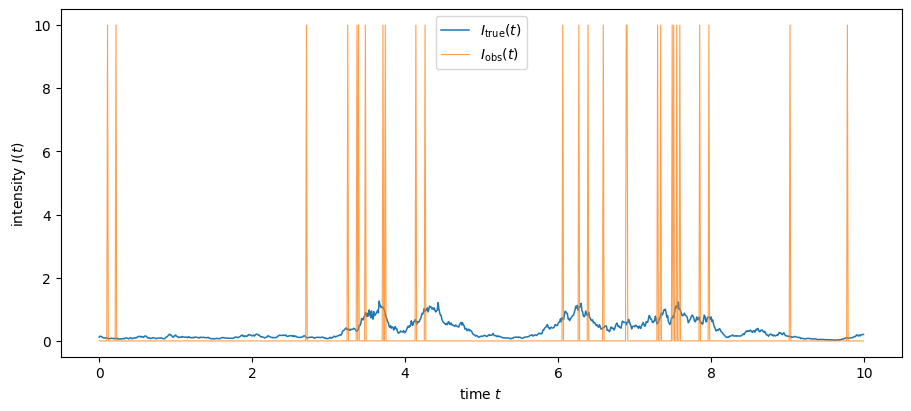

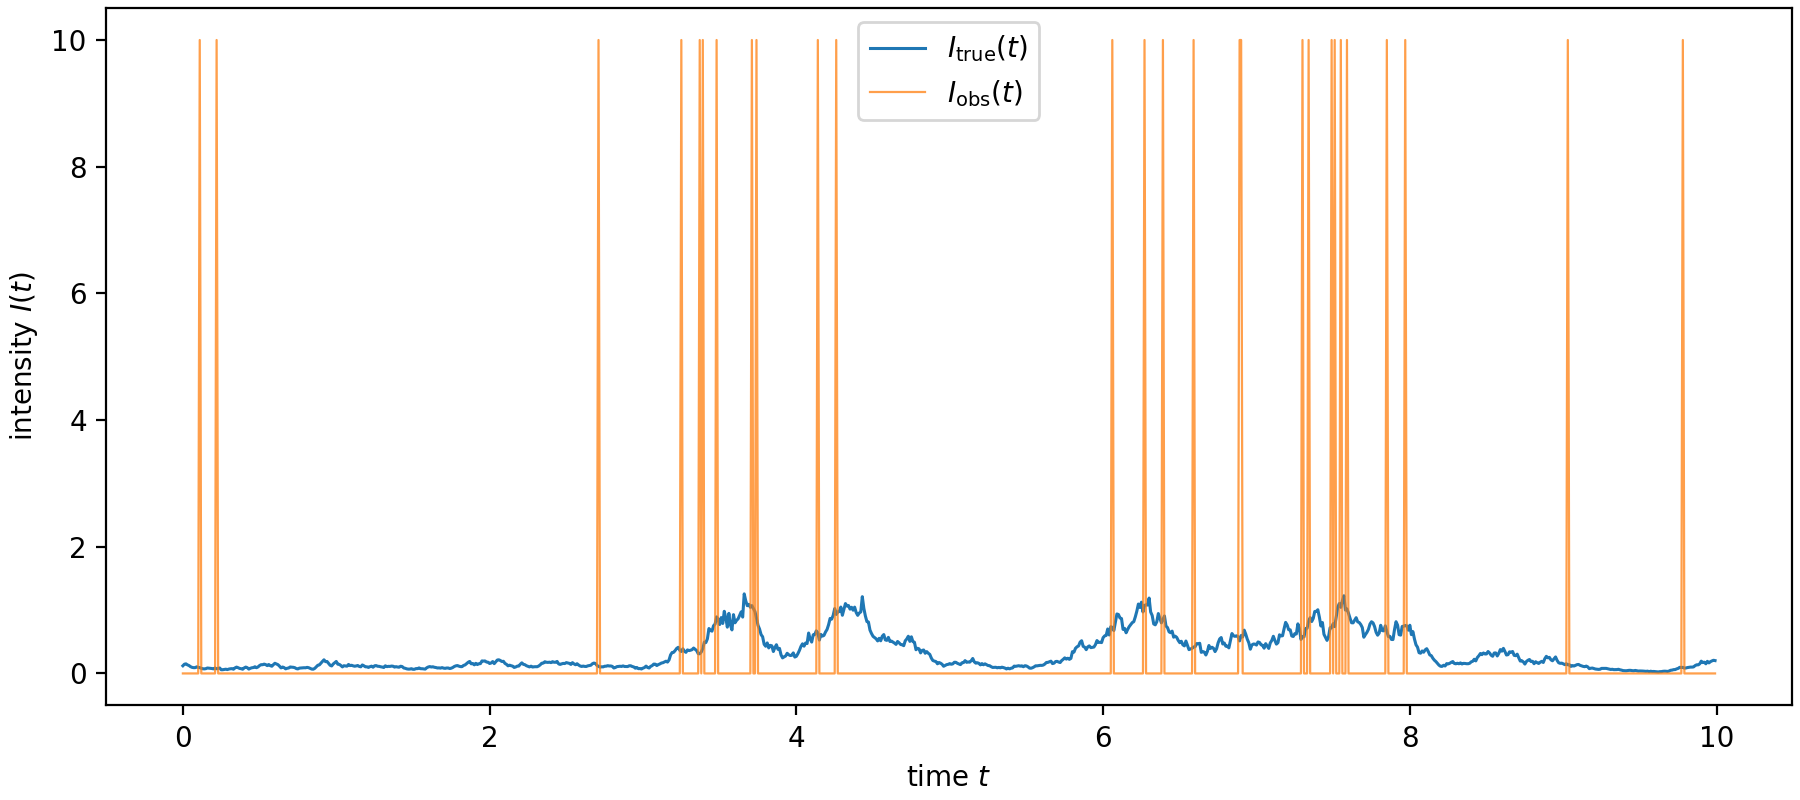

In [2]:
t, I_true, I_obs, metadata, correlation = bench.generate_observed_series(config)

print("model:", metadata.model_name)
print("model parameters:", metadata.model_params)
print("n samples:", metadata.n_samples)
print("observed zeros:", int(np.sum(I_obs == 0.0)))

view = slice(0, min(1000, t.size))
fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)
ax.plot(t[view], I_true[view], label=r"$I_{\mathrm{true}}(t)$", linewidth=1.1)
ax.plot(t[view], I_obs[view], label=r"$I_{\mathrm{obs}}(t)$", linewidth=0.8, alpha=0.75)
ax.set_xlabel(r"time $t$")
ax.set_ylabel(r"intensity $I(t)$")
ax.legend()
fig.savefig(OUTPUT_DIR / "synthetic_time_series.png", dpi=200)
plt.show()

display(Image(filename=str(OUTPUT_DIR / "synthetic_time_series.png")))

## 2. Visibility Calculation

Segment the same observed time series for each exposure time, estimate the noise-corrected visibility vector, and compute the diagonal uncertainty estimate.

number of exposure times: 31
T range: 0.01 5.0
Khat^2 range: 0.35111746142103345 1.0136743284766576
stderr range: 0.048357887710933925 0.07165683089260731


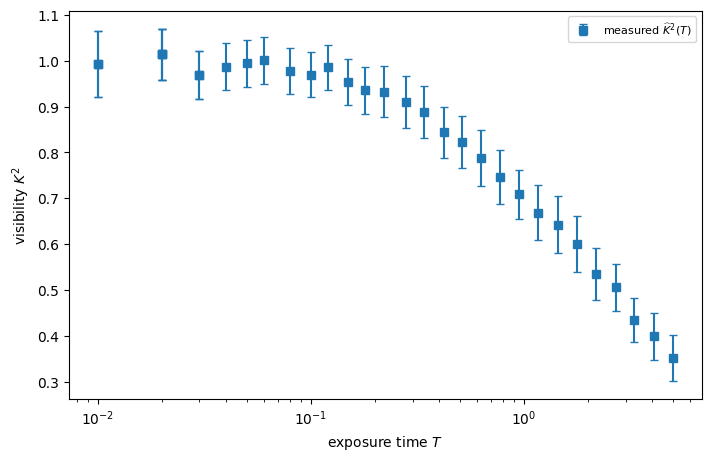

In [3]:
visibility, uncertainty, Sigma_K, _ = bench.estimate_visibility_and_covariance(I_obs, config)

print("number of exposure times:", visibility.effective_T_values.size)
print("T range:", float(np.min(visibility.effective_T_values)), float(np.max(visibility.effective_T_values)))
print("Khat^2 range:", float(np.min(visibility.Khat2)), float(np.max(visibility.Khat2)))
print("stderr range:", float(np.min(uncertainty.stderr)), float(np.max(uncertainty.stderr)))

fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
ax.errorbar(
    visibility.effective_T_values,
    visibility.Khat2,
    yerr=uncertainty.stderr,
    marker="s",
    capsize=3,
    linestyle="none",
    label=r"measured $\widehat{K}^2(T)$",
)
ax.set_xscale("log")
ax.set_xlabel(r"exposure time $T$")
ax.set_ylabel(r"visibility $K^2$")
ax.legend(fontsize=8)
plt.show()

## 3. Correlation Inversion

Use Bayesian/Gaussian-process inference to reconstruct the normalized autocorrelation from the measured visibility vector. Then regenerate the benchmark figures in the output folder.

In [4]:
reconstruction, true_C, prior_tau_c = bench.reconstruct_correlation(
    visibility,
    Sigma_K,
    I_obs,
    config,
)
pinv_C = bench.estimate_pinv_correlation(
    visibility,
    reconstruction.tau_grid,
    rcond=config.pinv_rcond,
)
calibrated_K, _, _ = bench.direct_visibility_calibration(I_obs, visibility, config)
metrics = bench.compute_metrics(
    I_obs,
    visibility,
    uncertainty,
    Sigma_K,
    reconstruction,
    true_C,
    prior_tau_c,
    calibrated_K,
    pinv_C,
)

print("MSE(C):", metrics.mse_C)
print("visibility chi-square:", metrics.visibility_chi_square)
print("reduced chi-square:", metrics.visibility_reduced_chi_square)
print("prior tau_c estimate:", metrics.prior_tau_c)

figures = bench.save_figures(
    OUTPUT_DIR,
    t,
    I_true,
    I_obs,
    correlation,
    visibility,
    uncertainty,
    reconstruction,
    true_C,
    pinv_C,
    calibrated_K,
    config,
)
figures

MSE(C): 0.0016131636450647613
visibility chi-square: 2.8563193670377123
reduced chi-square: 0.09213933442057136
prior tau_c estimate: 0.7684305194310774


{'synthetic_time_series': 'svs_benchmark_output_double_exp\\synthetic_time_series.png',
 'target_vs_empirical_autocorrelation': 'svs_benchmark_output_double_exp\\target_vs_empirical_autocorrelation.png',
 'measured_visibility': 'svs_benchmark_output_double_exp\\measured_visibility.png',
 'reconstructed_c': 'svs_benchmark_output_double_exp\\reconstructed_c.png',
 'visibility_residuals': 'svs_benchmark_output_double_exp\\visibility_residuals.png'}

### Reproduced Result Figures

synthetic_time_series


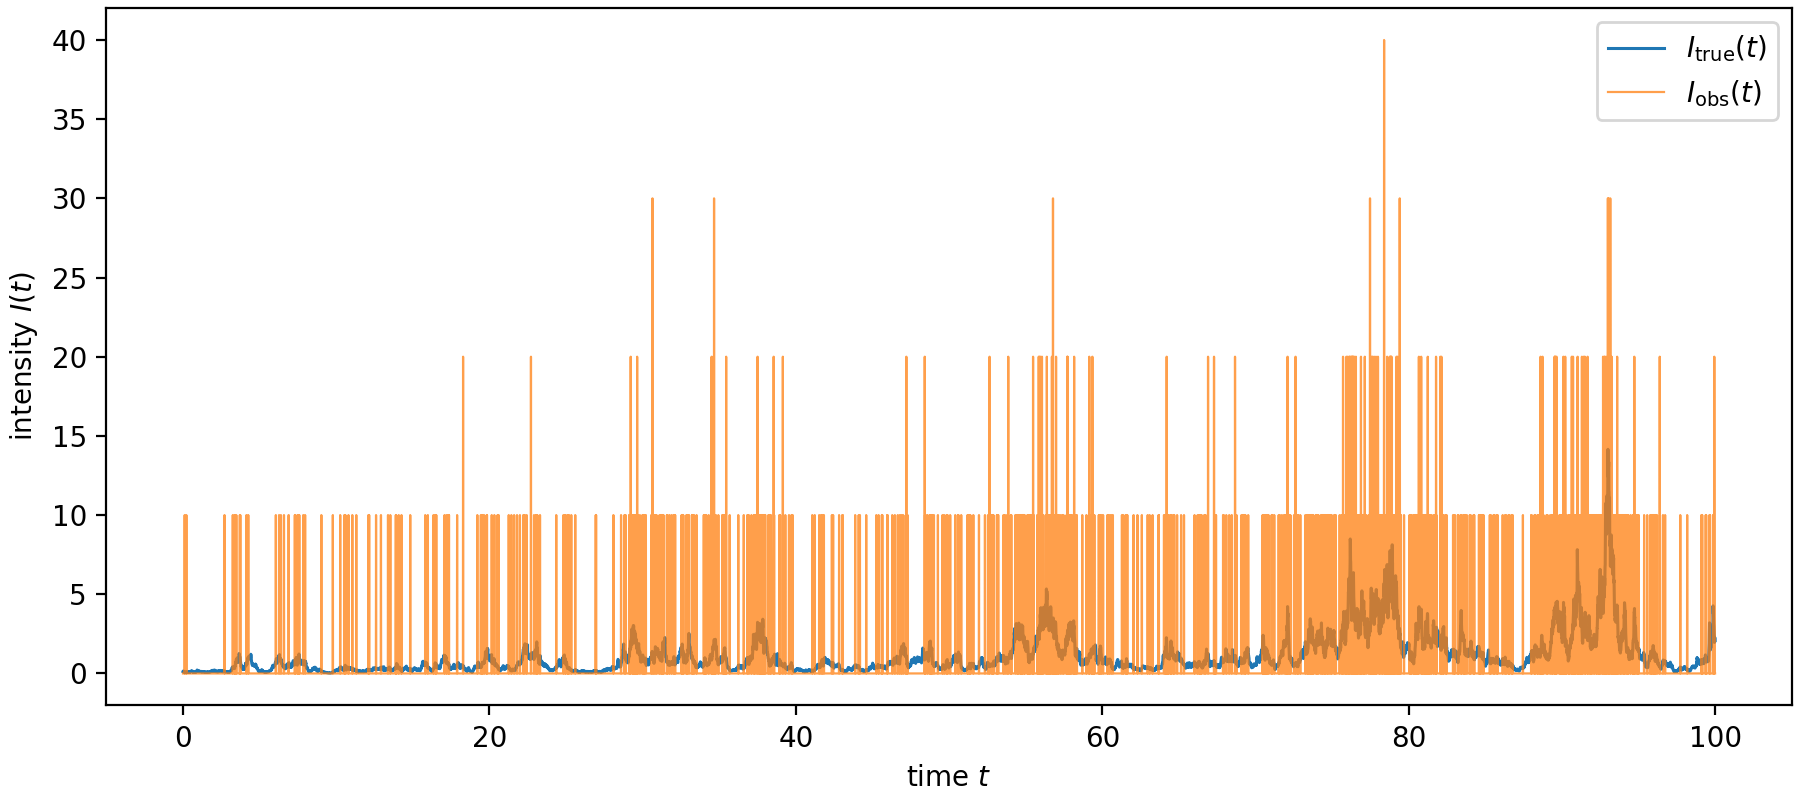

target_vs_empirical_autocorrelation


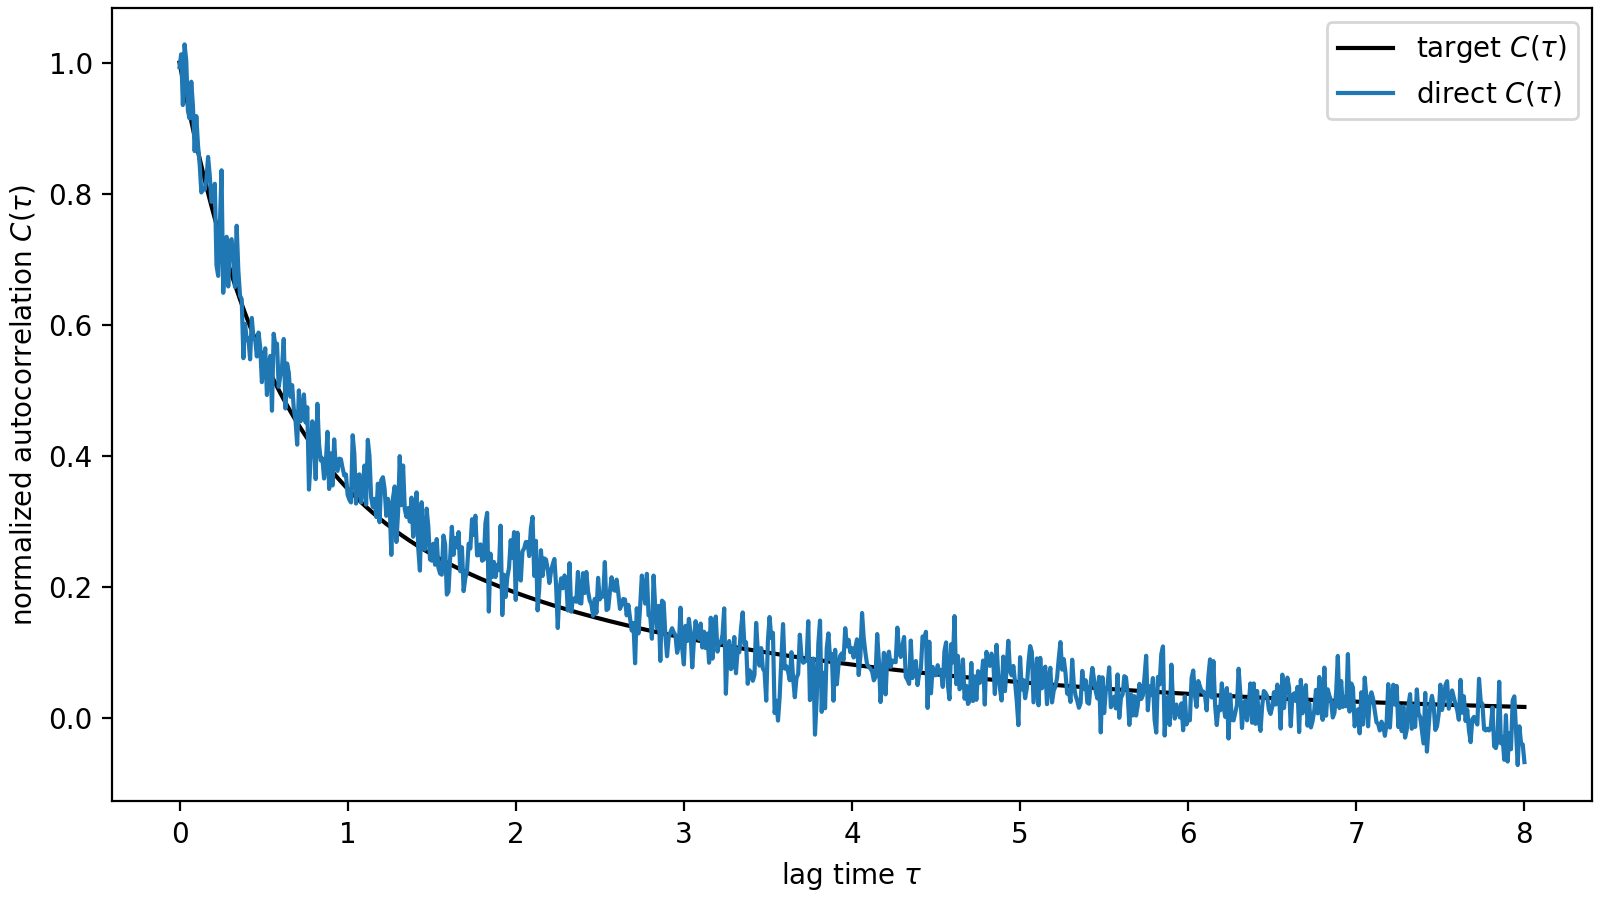

measured_visibility


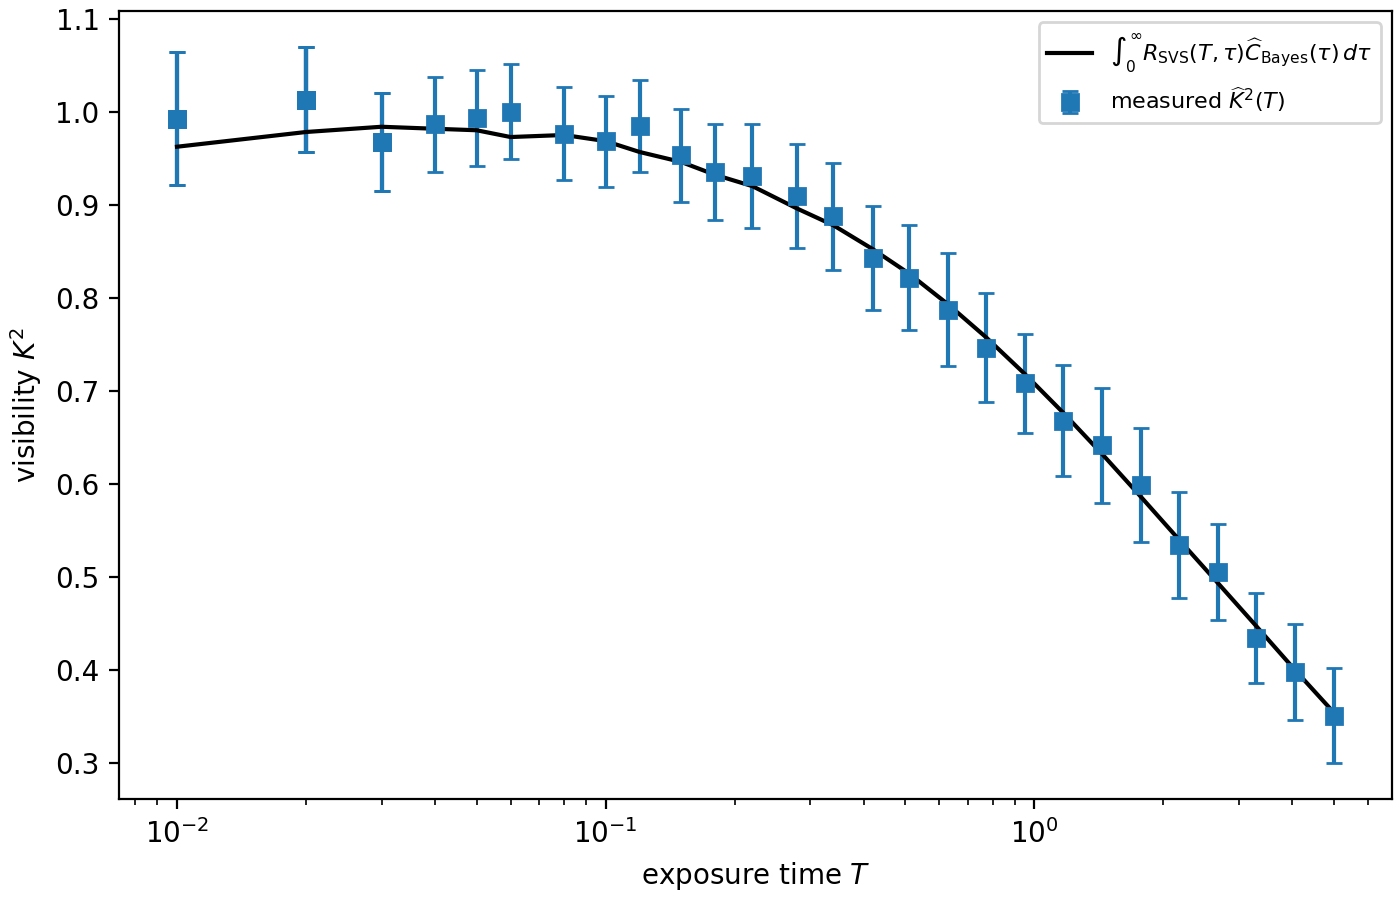

reconstructed_c


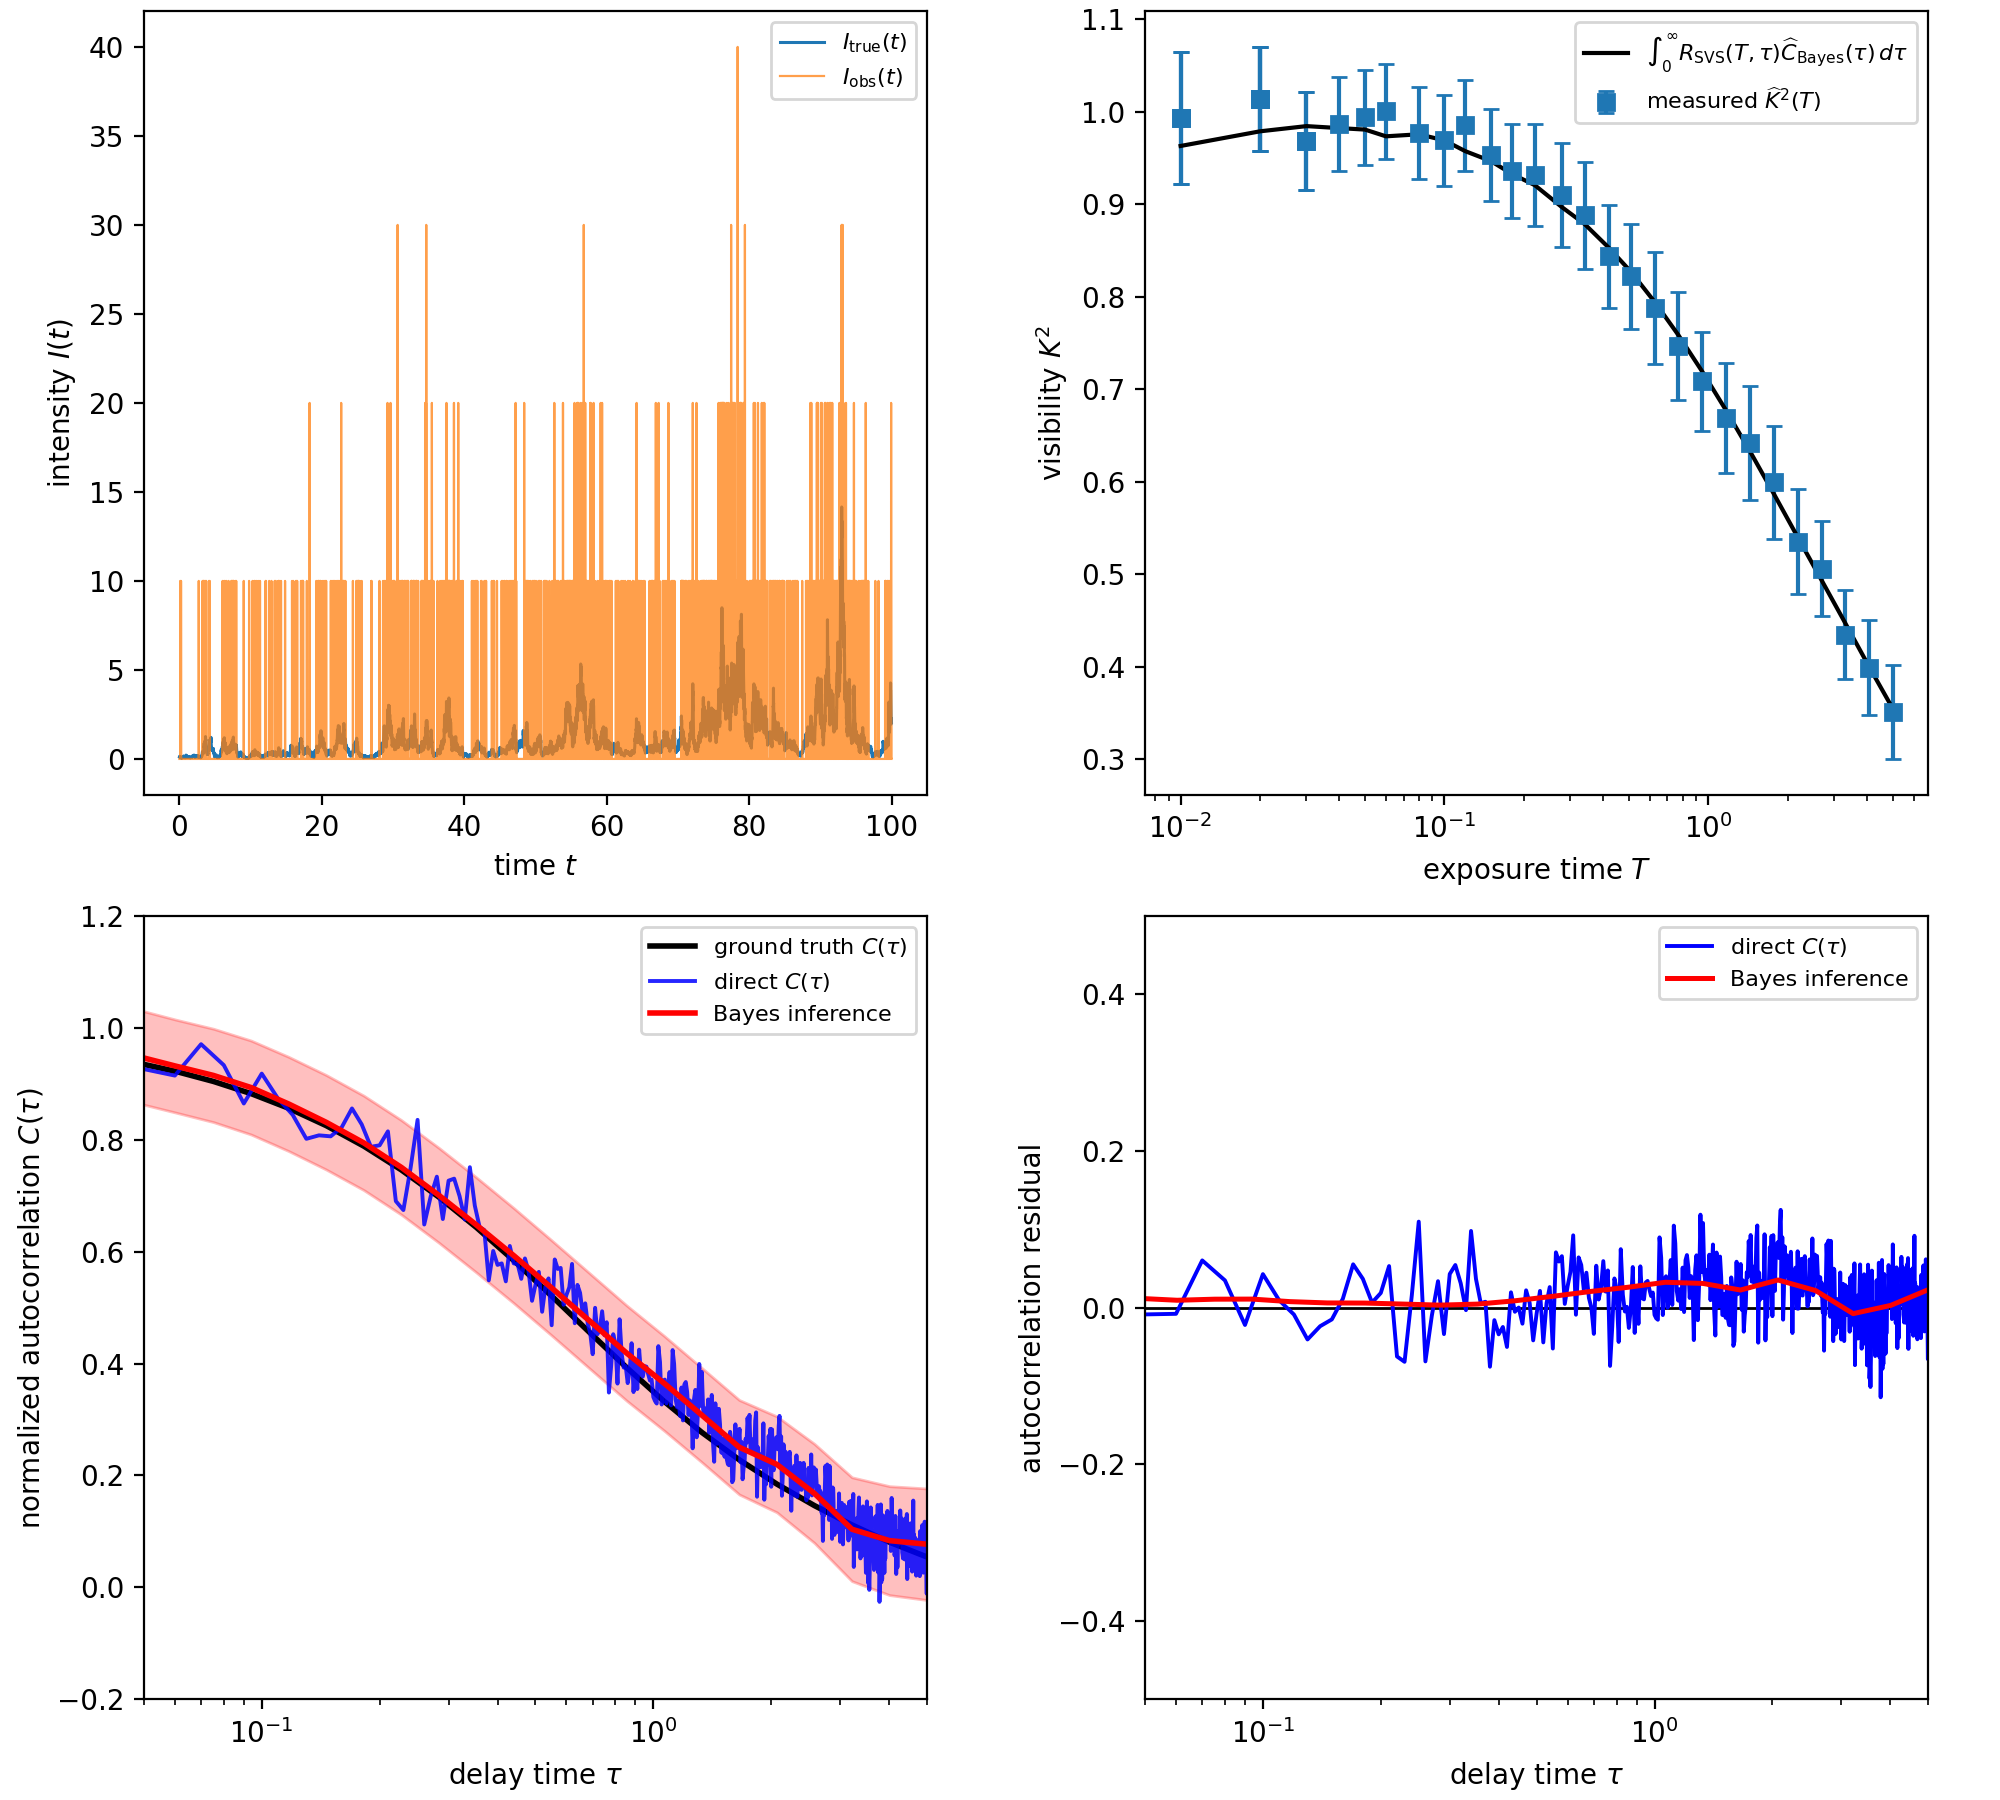

visibility_residuals


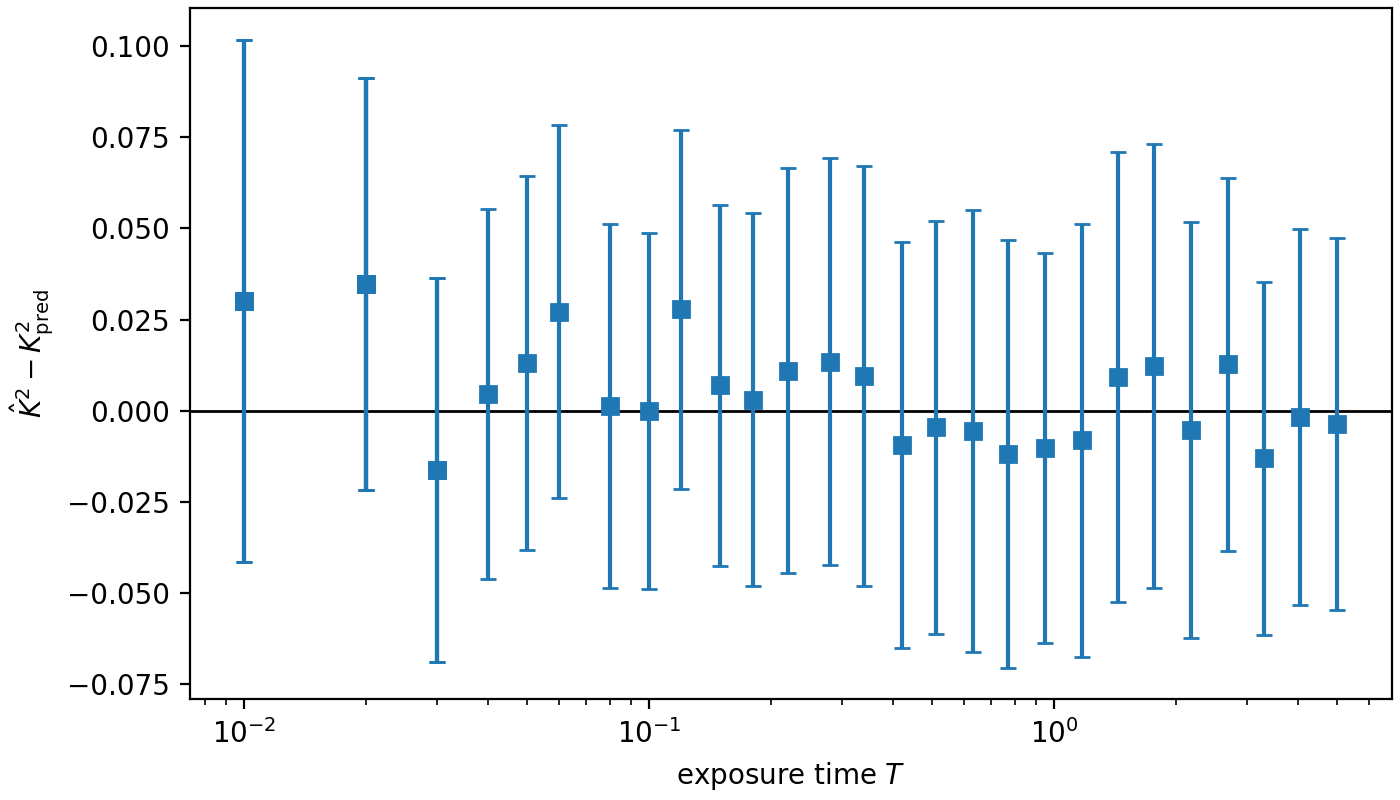

In [5]:
for name in [
    "synthetic_time_series",
    "target_vs_empirical_autocorrelation",
    "measured_visibility",
    "reconstructed_c",
    "visibility_residuals",
]:
    print(name)
    display(Image(filename=str(Path(figures[name]))))